In [114]:
import zipfile
import io
import pandas as pd
import re
import matplotlib.pyplot as plt
import numpy as np

مسیر برای خواندن و درک زیپ های تو در تو

In [62]:
path_main_zip=r"F:\DANESHKAR\tennis_project\Tennis Schema\tennis_data.zip"

def get_day_zip(day_name):
    z1=zipfile.ZipFile(path_main_zip)
    day_bytes=z1.open(f"{day_name}.zip").read()
    return zipfile.ZipFile(io.BytesIO(day_bytes))
    
def read_parquet(day_zip,path_inside_zip):
    raw_bytes=day_zip.open(path_inside_zip).read()
    return pd.read_parquet(io.BytesIO(raw_bytes))

def get_all_day_names():
    z1=zipfile.ZipFile(path_main_zip)
    return [n.replace(".zip","")for n in z1.namelist()if n.endswith(".zip")]



ساخت یک ردیف کامل برای یک مسابقه

In [63]:
def build_one_match(match_id,day_zip):
    prefix="../../data/raw"
    try:
        home = read_parquet(day_zip, f"{prefix}/raw_match_parquet/home_team_{match_id}.parquet")
        away = read_parquet(day_zip, f"{prefix}/raw_match_parquet/away_team_{match_id}.parquet")
        event = read_parquet(day_zip, f"{prefix}/raw_match_parquet/event_{match_id}.parquet")
        stats = read_parquet(day_zip, f"{prefix}/raw_statistics_parquet/statistics_{match_id}.parquet")
        tournament=read_parquet(day_zip,f"{prefix}/raw_match_parquet/tournament_{match_id}.parquet")
        round_info=read_parquet(day_zip,f"{prefix}/raw_match_parquet/round_{match_id}.parquet")
        time_info=read_parquet(day_zip,f"{prefix}/raw_match_parquet/time_{match_id}.parquet")
        home_score=read_parquet(day_zip,f"{prefix}/raw_match_parquet/home_team_score_{match_id}.parquet")
        away_score=read_parquet(day_zip,f"{prefix}/raw_match_parquet/away_team_score_{match_id}.parquet")

        home_small = home[["match_id", "player_id", "name", "gender", "height", "current_rank", "country", "plays"]].add_prefix("home_")
        away_small = away[["player_id", "name", "gender", "height", "current_rank", "country", "plays"]].add_prefix("away_")
        event_small = event[["winner_code", "start_datetime"]]
        tournament_small=tournament[["match_id","tournament_id","tournament_name","ground_type"]].rename(
            columns={"match_id":"tournament_match_id"}
        ) 
        round_small=round_info[["match_id","name","slug"]].rename(
            columns={"match_id":"round_match_id","name":"round_name","slug":"round_slug"}
        )
        period_cols=["period_1","period_2","period_3","period_4","period_5"]
        time_small=time_info[period_cols].copy()
        time_small["total_duration_seconds"]=time_small[period_cols].sum(axis=1)
        time_small=time_small["total_duration_seconds"]

        home_score_small=home_score[period_cols].add_prefix("home_games_")
        away_score_small=away_score[period_cols].add_prefix(("away_games_"))

        stats_wide = stats[stats["period"] == "ALL"].pivot(
            index="match_id", columns="statistic_name", values=["home_value", "away_value"]
        )
        stats_wide.columns = ["_".join(col) for col in stats_wide.columns]
        stats_wide = stats_wide.reset_index()

        row = pd.concat([
             home_small.reset_index(drop=True),
             away_small.reset_index(drop=True),
             event_small.reset_index(drop=True),
             tournament_small.reset_index(drop=True),
             round_small.reset_index(drop=True),
             time_small.reset_index(drop=True),
             home_score_small.reset_index(drop=True),
             away_score_small.reset_index(drop=True)],
            axis=1)
        
        row = row.merge(stats_wide, left_on="home_match_id", right_on="match_id")
        return row
    except Exception as e:
        print(f"»سابقه {match_id} رد شده {e}")
        return None
    
        
    

In [ ]:

#1
def build_final_table():
    

  all_rows = []
  day_names = get_all_day_names()
  print("تعداد کل روزها:", len(day_names))

  for day_name in day_names:
      day_zip = get_day_zip(day_name)
      names = day_zip.namelist()

      match_ids = set()
      for name in names:
          if "raw_match_parquet" in name:
              m = re.search(r"(\d+)\.parquet", name)
              if m:
                  match_ids.add(m.group(1))

      for mid in match_ids:
          result = build_one_match(mid, day_zip)
          if result is not None:
              result["day"] = day_name
              all_rows.append(result)

      print(f"روز {day_name} پردازش شد. مجموع مسابقات تا الان: {len(all_rows)}")

  final_table = pd.concat(all_rows, ignore_index=True)
  final_table = final_table.drop_duplicates(subset="match_id", keep="last")

  print("\nشکل نهایی جدول:", final_table.shape)
  final_table.to_parquet(r"F:\DANESHKAR\tennis_project\clean_matches_f3.parquet")
  print("جدول نهایی ذخیره شد")


In [ ]:
#2
all_rows = []
day_names = get_all_day_names()
print("تعداد کل روزها:", len(day_names))

for day_name in day_names:
    day_zip = get_day_zip(day_name)
    names = day_zip.namelist()

    match_ids = set()
    for name in names:
        if "raw_match_parquet" in name:
            m = re.search(r"(\d+)\.parquet", name)
            if m:
                match_ids.add(m.group(1))

    for mid in match_ids:
        result = build_one_match(mid, day_zip)
        if result is not None:
            result["day"] = day_name
            all_rows.append(result)

    print(f"روز {day_name} پردازش شد. مجموع مسابقات تا الان: {len(all_rows)}")

final_table = pd.concat(all_rows, ignore_index=True)
print("\nشکل نهایی جدول کامل قبل از حذف داده های تکراری:", final_table.shape)
# حذف مسابقاتی که چند روز تکرار شدن و فقط اخرین نسخه را نگه میدارد
final_table=final_table.sort_values("day")
final_table=final_table.drop_duplicates(subset="match_id", keep="last")
print("شکل نهایی جدول بعد از حذف داده های تکراری",final_table.shape)

# ذخیره‌ی جدول روی دیسک، تا دیگر لازم نباشد این پردازش سنگین تکرار شود
final_table.to_parquet(r"F:\DANESHKAR\tennis_project\clean_matches_f3.parquet")
print("جدول نهایی ذخیره شد")
final_table=build_final_table()



تعداد کل روزها: 60
»سابقه 11974049 رد شده "There is no item named '../../data/raw/raw_match_parquet/home_team_11974049.parquet' in the archive"
»سابقه 12041794 رد شده "There is no item named '../../data/raw/raw_match_parquet/round_12041794.parquet' in the archive"
»سابقه 12041834 رد شده "There is no item named '../../data/raw/raw_match_parquet/round_12041834.parquet' in the archive"
»سابقه 12042778 رد شده "There is no item named '../../data/raw/raw_statistics_parquet/statistics_12042778.parquet' in the archive"
»سابقه 12039846 رد شده "There is no item named '../../data/raw/raw_match_parquet/round_12039846.parquet' in the archive"
»سابقه 12041853 رد شده "There is no item named '../../data/raw/raw_match_parquet/round_12041853.parquet' in the archive"
»سابقه 12041644 رد شده "There is no item named '../../data/raw/raw_match_parquet/home_team_12041644.parquet' in the archive"
»سابقه 12040592 رد شده "There is no item named '../../data/raw/raw_match_parquet/round_12040592.parquet' in the arch

In [67]:
FINAL_PATH=r"F:\DANESHKAR\tennis_project\clean_matches_f3.parquet"
df=pd.read_parquet(FINAL_PATH)
print("total_duration_seconds" in df.columns)

True


In [118]:
df_check=pd.read_parquet(FINAL_PATH)
print(df_check.shape)


(7662, 77)


q7:

In [69]:
df=pd.read_parquet(r"F:\DANESHKAR\tennis_project\clean_matches_f3.parquet")
print("تعداد کل مسابقات در جدول",df.shape[0])
print("تعداد کل ستون ها",df.shape[1])

print("ستون های مرتبط با ایس",[c for c in df.columns if "aces" in c])

aces_df=df[["home_value_aces","away_value_aces","home_gender"]]
print("قبل از پاکسازی:")
print("تعداد کل ردیف ها",len(aces_df))
print("مقادیر خالی home:",aces_df["home_value_aces"].isna().sum())
print("مقادیر خالیaway:",aces_df["away_value_aces"].isna().sum())
aces_df["home_value_aces"]=pd.to_numeric(aces_df["home_value_aces"],errors="coerce")
aces_df["away_value_aces"]=pd.to_numeric(aces_df["away_value_aces"],errors="coerce")
aces_df=aces_df.dropna(subset=["home_value_aces","away_value_aces"],how="all")

print("بیشترین مقدار home:",aces_df["home_value_aces"].max())
print("بیشترین مقدار away:",aces_df["away_value_aces"].max())

# aces_df=aces_df[(aces_df["home_value_aces"].fillna(0)>=0)&(aces_df["away_value_aces"]fillna(0)>=0)]

print("بعد ار پاکسازی:")
print("تعداد ردیف های باقی مانده:",len(aces_df))

aces_df["total_aces"]=aces_df["home_value_aces"].fillna(0)+aces_df["away_value_aces"].fillna(0)

print("نتایج سوال7:")
print("میانگین ایس در هر مسابقه",round(aces_df["total_aces"].mean(),2))
print("میانه ایس در هر مسابقه:",aces_df["total_aces"].median())
print("انحراف معیار :",round(aces_df["total_aces"].std(),2))
print("کمترین تعداد ایس در یم مسابقه:",aces_df["total_aces"].min())
print("بیشترین تعداد ایس در یک مسابقه:",aces_df["total_aces"].max())

# print(aces_df["home_gender"].unique())
# print(aces_df["home_gender"].value_counts())
men=aces_df[aces_df["home_gender"]=="M"]
women=aces_df[aces_df["home_gender"]=="F"]
print("میانگین ایس در مسابقات مردان:",round(men["total_aces"].mean(),2))
print("میانگین ایس در مسابقات زنان",round(women["total_aces"].mean(),2))
print("تعداد مقادیر منفی home:",(aces_df["home_value_aces"]<0).sum())
print("تعداد مقادیر منفی away:",(aces_df["away_value_aces"]<0).sum())
print("تعداد مقادیر منفی total:",(aces_df["total_aces"]<0).sum())
print("تعداد مقادیر غیر ممکن:",(aces_df["total_aces"]>150).sum())
print(aces_df["home_value_aces"].dtype)
print(aces_df["away_value_aces"].dtype)
non_injteger_home=aces_df[aces_df["home_value_aces"]%1!=0]
print("تعداد مقادیر غیر صحیح در home",len(non_injteger_home))
#dublicate
print("کل ردیف ها",len(aces_df))
print("تعداد match id  یکتا",aces_df.index.nunique() if "match_ids" not in aces_df.columns else aces_df["match_ids"].nunique())
#ok


تعداد کل مسابقات در جدول 7662
تعداد کل ستون ها 77
ستون های مرتبط با ایس ['home_value_aces', 'away_value_aces']
قبل از پاکسازی:
تعداد کل ردیف ها 7662
مقادیر خالی home: 4
مقادیر خالیaway: 4
بیشترین مقدار home: 38.0
بیشترین مقدار away: 39.0
بعد ار پاکسازی:
تعداد ردیف های باقی مانده: 7658
نتایج سوال7:
میانگین ایس در هر مسابقه 5.92
میانه ایس در هر مسابقه: 4.0
انحراف معیار : 5.63
کمترین تعداد ایس در یم مسابقه: 0.0
بیشترین تعداد ایس در یک مسابقه: 51.0
میانگین ایس در مسابقات مردان: 7.54
میانگین ایس در مسابقات زنان 3.78
تعداد مقادیر منفی home: 0
تعداد مقادیر منفی away: 0
تعداد مقادیر منفی total: 0
تعداد مقادیر غیر ممکن: 0
float64
float64
تعداد مقادیر غیر صحیح در home 0
کل ردیف ها 7658
تعداد match id  یکتا 7658


histogram 7:

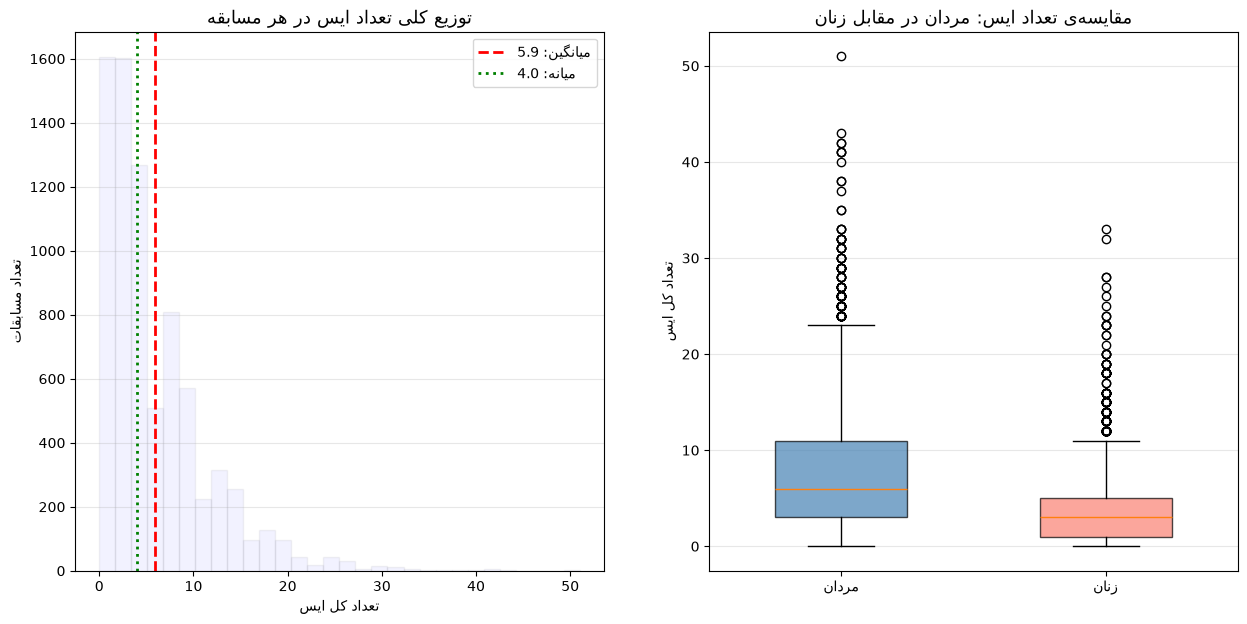

In [70]:
fig, (ax1,ax2)=plt.subplots(1,2,figsize=(15,7))

ax1.hist(aces_df["total_aces"],bins=30,color="blue",edgecolor="black",alpha=.05)


# خط عمودی برای میانگین
mean_val = aces_df["total_aces"].mean()
ax1.axvline(
    mean_val,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"میانگین: {mean_val:.1f}"
)

# خط عمودی برای میانه (برای مقایسه با میانگین)
median_val = aces_df["total_aces"].median()
ax1.axvline(
    median_val,
    color="green",
    linestyle=":",
    linewidth=2,
    label=f"میانه: {median_val:.1f}"
)

ax1.set_title("توزیع کلی تعداد ایس در هر مسابقه", fontsize=13)
ax1.set_xlabel("تعداد کل ایس")
ax1.set_ylabel("تعداد مسابقات")
ax1.legend()
ax1.grid(axis="y", alpha=0.3)

# ----------------------------------------------------------
# نمودار ۲ (ax2): مقایسه‌ی ایس بین مرد و زن (Box Plot)
# ----------------------------------------------------------
men_aces = aces_df[aces_df["home_gender"] == "M"]["total_aces"].dropna()
women_aces = aces_df[aces_df["home_gender"] == "F"]["total_aces"].dropna()

box = ax2.boxplot(
    [men_aces, women_aces],
    tick_labels=["مردان", "زنان"],
    patch_artist=True,
    widths=0.5
)

# رنگ‌آمیزی جعبه‌ها
colors = ["steelblue", "salmon"]
for patch, color in zip(box["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax2.set_title("مقایسه‌ی تعداد ایس: مردان در مقابل زنان", fontsize=13)
ax2.set_ylabel("تعداد کل ایس")
ax2.grid(axis="y", alpha=0.3)

#save chart مونده اونو کامل کن

q8:
بررسی تعداد دبل فالت بر اساس جنسیت

In [71]:
#بررسی اینکه  ایا مسابقه ای در جدول دوبار تکرار شده و باگ در این مسئله داریم؟
duplicate_check=pd.DataFrame({
    "metric":["total_rows","unique_matches","duplicate_rows"],
    "value":[len(df),df["home_match_id"].nunique(),df["home_match_id"].duplicated().sum()]
})
display(duplicate_check)

if df["home_match_id"].duplicated().sum()>0:
     df=df.drop_duplicates(subset=["home_match_id"],keep="first")
#جدول وضعیت اولیه دیتا قبل پاکسازی
faults_df=df[["home_value_double_faults","away_value_double_faults","home_gender","away_gender"]].copy()
display(faults_df)

befor_q8=pd.DataFrame({
     "metric":["total_rows","missing_home","missing_away","max_home","max_away"],
     "vallue":[
          len(faults_df),
          faults_df["home_value_double_faults"].isna().sum(),
          faults_df["away_value_double_faults"].isna().sum(),
          faults_df["home_value_double_faults"].max(),
          faults_df["away_value_double_faults"].max()]
})
display(befor_q8)

#data cleaning:
faults_df["home_value_double_faults"]=pd.to_numeric(faults_df["home_value_double_faults"],errors="coerce")
faults_df["away_value_double_faults"]=pd.to_numeric(faults_df["away_value_double_faults"],errors="coerce")

#حذف ردیف هایی که ه ر دو طرف خالی دارند
faults_df=faults_df.dropna(subset=["home_value_double_faults"],how="all")

#منطق برای بازی تنیس ،دبل فالت باید مثبت باشه وو یک سقفی براش باشد ، 
#با فرض اینکه طولانی ترین بازی 5 ست باشداگر دبل بیش از 30 باشد عدد غیر منطقی است
#سقف را 30 در نظر گرفتم
max_resonable_double_faults=30
faults_df=faults_df[
     (faults_df["home_value_double_faults"].fillna(0).between(0,max_resonable_double_faults))&
     (faults_df["away_value_double_faults"].fillna(0).between(0,max_resonable_double_faults))
]
#وضعیت دیتا بعد از پاکسازی
after_q8=pd.DataFrame({
     "metric":["rows_remaining"],
     "value":[len(faults_df)]
})
display(after_q8)

#تبدیل به شکل بلند ،یعنی هر بازیکن یک ردیف جدا باشد
#زیرا برای مقایسه جنسیتی باید هر بازیکن در یک ردیف مستقل باشد
home_side=faults_df[["home_gender","home_value_double_faults"]].rename(
     columns={"home_gender":"gender","home_value_double_faults":"double_faults"})
away_side=faults_df[["away_gender","away_value_double_faults"]].rename(
     columns={"away_gender":"gender","away_value_double_faults":"double_faults"})
players_faults=pd.concat([home_side,away_side],ignore_index=True)
players_faults=players_faults.dropna(subset=["double_faults","gender"])

players_faults=players_faults[players_faults["gender"].isin(["M","F"])]
#اینجا کدی بزنم که اسم جنسیت های دیگرو تبدیل کنم

summary_q8=players_faults.groupby("gender")["double_faults"].agg(
     mean="mean",meadian="median",std="std",min="min",max="max",count="count").round(2).reset_index()
summary_q8["gender"]=summary_q8["gender"].replace({"M":"Men","F":"Women"})

#محاسبه درصد اختلاف
mean_m=players_faults[players_faults["gender"]=="M"]["double_faults"].mean()
mean_f=players_faults[players_faults["gender"]=="F"]["double_faults"].mean()
diff_percent=abs(mean_m-mean_f)/((mean_f+mean_m)/2)*100

diff_table_8=pd.DataFrame({
     "metric":["mean_men","mean_women","difference_percent"],
     "value":[mean_m,mean_f,diff_percent]
})
display(diff_table_8)



,metric,value
0,total_rows,7662
1,unique_matches,7662
2,duplicate_rows,0


,home_value_double_faults,away_value_double_faults,home_gender,away_gender
27,3.0,0.0,M,M
157,4.0,1.0,F,F
158,2.0,1.0,M,M
165,5.0,2.0,M,M
166,4.0,0.0,M,M
...,...,...,...,...
15540,0.0,5.0,M,M
15541,2.0,2.0,M,M
15542,2.0,3.0,F,F
15543,0.0,2.0,M,M


,metric,vallue
0,total_rows,7662.0
1,missing_home,4.0
2,missing_away,4.0
3,max_home,31.0
4,max_away,21.0


,metric,value
0,rows_remaining,7657


,metric,value
0,mean_men,2.690907
1,mean_women,3.521401
2,difference_percent,26.737062


histogram q8

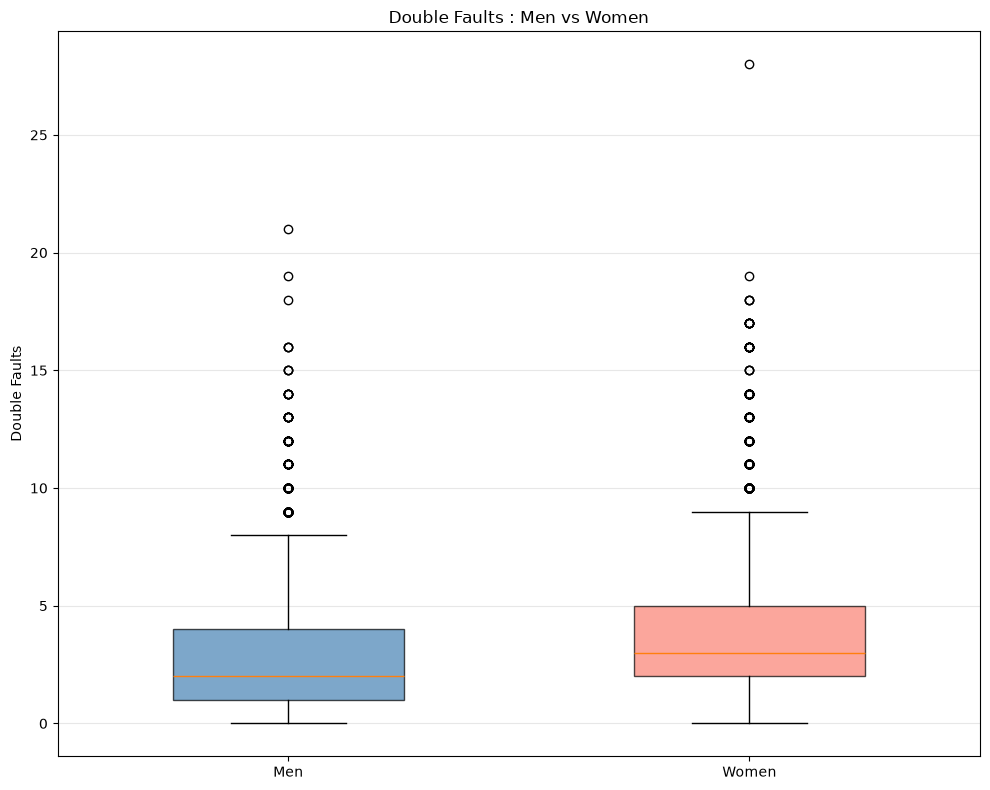

In [72]:
fig, ax=plt.subplots(figsize=(10,8))
men_data=players_faults[players_faults["gender"]=="M"]["double_faults"]
women_data=players_faults[players_faults["gender"]=="F"]["double_faults"]

box=ax.boxplot([men_data,women_data],tick_labels=["Men","Women"],patch_artist=True,widths=0.5)

for patch,color in zip(box["boxes"],["steelblue","salmon"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title("Double Faults : Men vs Women")
ax.set_ylabel("Double Faults")
ax.grid(axis="y",alpha=0.3)
fig.tight_layout()

#fig.savefig
plt.show()

q9:
کدام بازیکن در یک ماه بیشترین تعداد مسابقات را داشته

In [77]:

df=pd.read_parquet(FINAL_PATH)
needed_cols=["tournament_id","round_name","winner_code","start_datetime"]
missing=[c for c in needed_cols if c not in df.columns]
column_check=pd.DataFrame({
    "column":needed_cols,
    "available":[c not in missing for c in needed_cols]
})
display(column_check)

champs_df=df[["tournament_id","round_name","winner_code","start_datetime","home_name","away_name"]].copy()
befor_q9=pd.DataFrame({
    "metric":["total_rows"]
})
befor_q9=pd.DataFrame({
    "metric":["total_rows","missing_round_name","missing_tournament_id"],
    "value":[len(champs_df),champs_df["round_name"].isna().sum(),champs_df["tournament_id"].isna().sum()]
})
display(befor_q9)

unique_rounds=pd.DataFrame(({"round_name":champs_df["round_name"].dropna().unique()}))
display(unique_rounds)
champs_df=champs_df.dropna(subset=["round_name","tournament_id","winner_code","start_datetime"])

final_df=champs_df[champs_df["round_name"]=="final"].copy()

after_q9=pd.DataFrame({
    "metric":["totat_matches","total_finals"],
    "value":[len(champs_df),len(final_df)]
})
display(after_q9)


#منطق تنیس وقتی winner code=1 یعنی برنده خانگی بوده و دو یعنی مهمان بوده
final_df["winner_name"]=final_df.apply(
    lambda r:r["home_name"] if r["winner_code"]==1 else r["away_name"],axis=1)

final_df["match_date"]=pd.to_datetime(final_df["start_datetime"],unit="s")
final_df["month"]=final_df["match_date"].dt.to_period("M")

champion_counts=final_df.groupby(["winner_name","month"]).size().reset_index(name="championship_count")
champion_counts=champion_counts.sort_values("championship_count",ascending=False)


,column,available
0,tournament_id,True
1,round_name,True
2,winner_code,True
3,start_datetime,True


,metric,value
0,total_rows,7662
1,missing_round_name,0
2,missing_tournament_id,0


,round_name
0,Round of 32
1,Round of 16
2,Quarterfinal
3,Qualification round 1
4,Semifinal
5,Final
6,Round of 64
7,Semifinals
8,Quarterfinals
9,Qualification round 2


,metric,value
0,totat_matches,7654
1,total_finals,0


q10:

In [74]:
home_players=df[["home_name","home_height","home_current_rank"]].rename(
    columns={"home_name":"name","home_height":"height","home_current_rank":"rank"}
)
away_players=df[["away_name","away_height","away_current_rank"]].rename(
    columns={"away_name":"name","away_height":"height","away_current_rank":"rank"}
)

all_players=pd.concat([home_players,away_players],ignore_index=True)

befor_q10=pd.DataFrame({
    "metric":["total_records","missing_height","misssing_rank"],
    "value":[len(all_players),all_players["height"].isna().sum(),all_players["rank"].isna().sum()]
})
display(befor_q10)

all_players["height"]=pd.to_numeric(all_players["height"],errors="coerce")
all_players["rank"]=pd.to_numeric(all_players["rank"],errors="coerce")
all_players=all_players.dropna(subset=["height","rank"])

#منطق واقعی برای قد
all_players=all_players[all_players["height"].between(1.5,2.2)]
all_players[all_players["rank"]>0]

unique_players=all_players.drop_duplicates(subset=["name"])

after_q10=pd.DataFrame({
    "metric":["rows_after_cleaning","unique_players"],
    "value":[len(all_players),len(unique_players)]
})
display(after_q10)

correlation=unique_players["height"].corr(unique_players["rank"])
summary_q10=pd.DataFrame({
    "metric":["correlation","mean_height","mean_rank","total_players"],
    "value":[round(correlation,3),round(unique_players["height"].mean(),2),round(unique_players["rank"].mean(),0),len(unique_players)]
})
display(summary_q10)


,metric,value
0,total_records,15324
1,missing_height,5523
2,misssing_rank,52


,metric,value
0,rows_after_cleaning,9790
1,unique_players,1223


,metric,value
0,correlation,0.109
1,mean_height,1.820
2,mean_rank,529.000
3,total_players,1223.000


نمودار سوال 10 نصفه

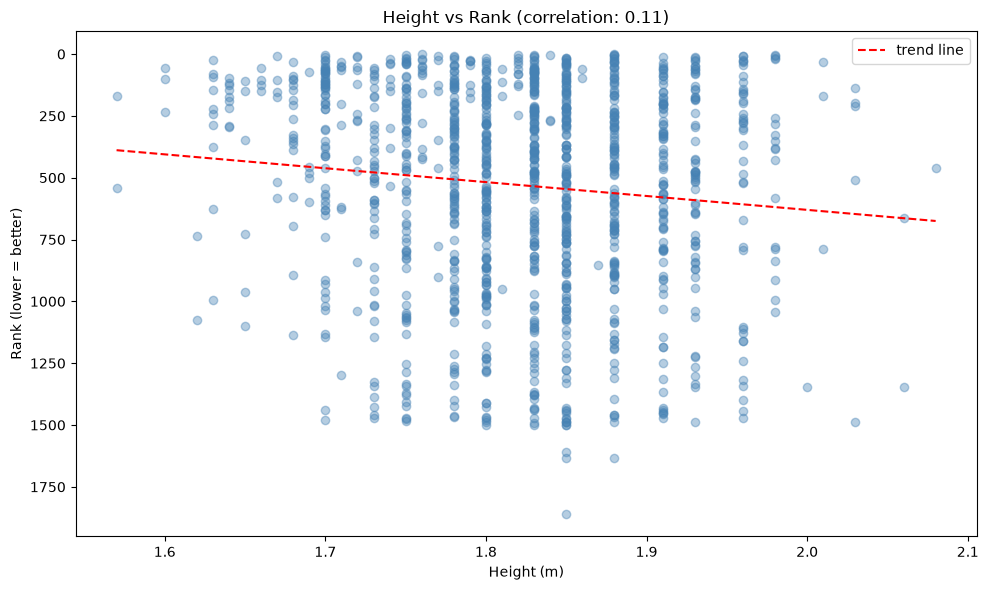

In [116]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(unique_players["height"], unique_players["rank"], alpha=0.4, color="steelblue")

# محاسبه و رسم خط روند خطی
z = np.polyfit(unique_players["height"], unique_players["rank"], 1)
p = np.poly1d(z)
x_line = np.linspace(unique_players["height"].min(), unique_players["height"].max(), 100)
ax.plot(x_line, p(x_line), color="red", linestyle="--", label="trend line")

ax.set_title(f"Height vs Rank (correlation: {correlation:.2f})")
ax.set_xlabel("Height (m)")
ax.set_ylabel("Rank (lower = better)")
# چون رنکینگ کوچک‌تر بهتر است، محور y را برعکس می‌کنیم تا نمودار طبیعی‌تر دیده شود
ax.invert_yaxis()
ax.legend()
fig.tight_layout()

# ذخیره‌ی نمودار برای ارائه
# fig.savefig("../charts/q10_height_rank_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

q11:
میانگین مدت زمان مسابقه

In [87]:
FINAL_PATH=r"F:\DANESHKAR\tennis_project\clean_matches_f3.parquet"
df=pd.read_parquet(FINAL_PATH)
print("total_duration_seconds" in df.columns)

print("total_rows=",len(df))
unique_matches=df["home_match_id"].unique()
number_of_duplicates=df["home_match_id"].duplicated().sum()
print("unique matches:",unique_matches)
print("number of duplicates",number_of_duplicates)

if number_of_duplicates>0:
    df=df.drop_duplicates(subset=["home_match_id"],keep="first")

duration_df=df[["total_duration_seconds"]].copy()
print("قبل پاکسازی:")
print("تعداد ردیف ها",len(duration_df))
print("مقادیر خالی:",duration_df["total_duration_seconds"].isna().sum())
duration_df["total_duration_seconds"]=pd.to_numeric(duration_df["total_duration_seconds"],errors="coerce")
duration_df=duration_df.dropna(subset=["total_duration_seconds"])
duration_df=duration_df[duration_df["total_duration_seconds"]>0]

duration_df=duration_df[
    (duration_df["total_duration_seconds"]>=1200)&
    (duration_df["total_duration_seconds"]<=21600)]

print("تعداد ردیف های باقی مانده:",len(duration_df))
duration_df["total_duration_minutes"]=duration_df["total_duration_seconds"]/60

result_q11=pd.DataFrame({
    "metric":["mean_minutes","median_minutes","std_minutes","min_minutes","max_minutes"],
    "value":[
        round(duration_df["total_duration_minutes"].mean(),1),
        round(duration_df["total_duration_minutes"].median(),1),
        round(duration_df["total_duration_minutes"].std(),1),
        round(duration_df["total_duration_minutes"].min(),1),
        round(duration_df["total_duration_minutes"].max(),1)
    ]
})
display(result_q11)



True
total_rows= 7662
unique matches: [12046412 12041896 12037716 ... 12027984 12028957 11998773]
number of duplicates 0
قبل پاکسازی:
تعداد ردیف ها 7662
مقادیر خالی: 0
تعداد ردیف های باقی مانده: 7420


,metric,value
0,mean_minutes,108.0
1,median_minutes,100.8
2,std_minutes,37.2
3,min_minutes,23.4
4,max_minutes,355.6


histo11

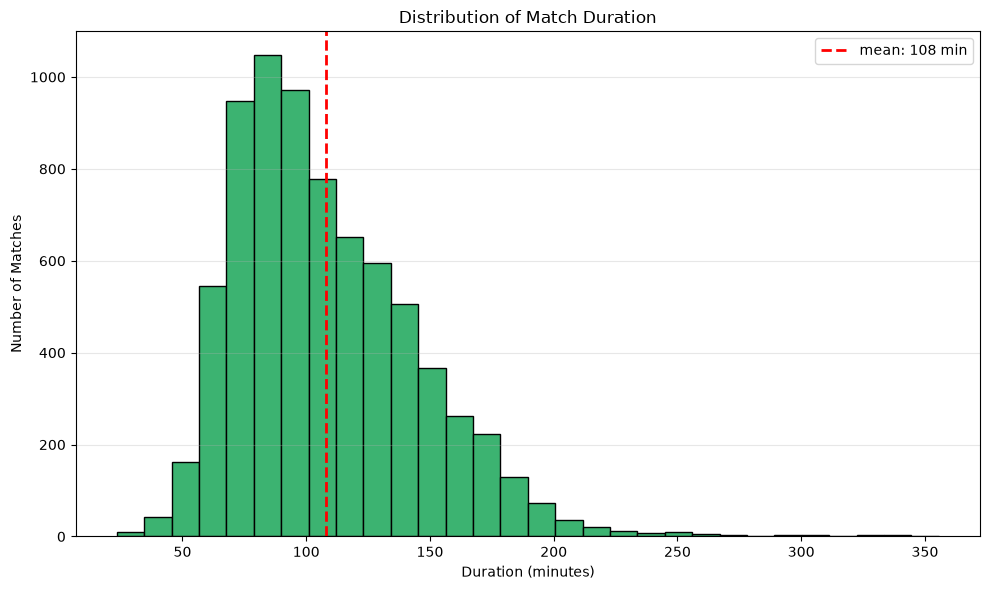

In [88]:
fig, ax = plt.subplots(figsize=(10, 6))

# هیستوگرام توزیع مدت‌زمان مسابقات را رسم می‌کنیم
ax.hist(duration_df["total_duration_minutes"], bins=30, color="mediumseagreen", edgecolor="black")

# یک خط عمودی قرمز روی میانگین رسم می‌کنیم
mean_val = duration_df["total_duration_minutes"].mean()
ax.axvline(mean_val, color="red", linestyle="--", linewidth=2, label=f"mean: {mean_val:.0f} min")

# عنوان و برچسب محورها را تنظیم می‌کنیم
ax.set_title("Distribution of Match Duration")
ax.set_xlabel("Duration (minutes)")
ax.set_ylabel("Number of Matches")
ax.legend()
ax.grid(axis="y", alpha=0.3)

# فاصله‌ها را خودکار تنظیم می‌کنیم
fig.tight_layout()

# نمودار را برای استفاده در ارائه ذخیره می‌کنیم
plt.show()

q12:
میانگین گیم در هر ست مردان مقابل زنان

In [113]:
home_games_cols = ["home_games_period_1", "home_games_period_2", "home_games_period_3","home_games_period_4", "home_games_period_5"]
away_games_cols = ["away_games_period_1", "away_games_period_2", "away_games_period_3","away_games_period_4", "away_games_period_5"]
games_df = df[home_games_cols + away_games_cols + ["home_gender"]].copy()

print("قبل از پاکسازی:")
print("تعداد کل ردیف‌ها (مسابقات):", len(games_df))

# با یک حلقه، تک‌ تک ستون‌های گیم (هم خانگی هم مهمان) را به عدد تبدیل می‌کنیم
for col in home_games_cols + away_games_cols:
    games_df[col] = pd.to_numeric(games_df[col], errors="coerce")

games_per_set_list = []
for i in range(1, 6):
   
    home_col = f"home_games_period_{i}"
    away_col = f"away_games_period_{i}"    
    valid_rows = games_df[games_df[home_col].notna() & games_df[away_col].notna()]

    # منطق تنیس: اگر هر دو طرف صفر گیم داشته باشند، یعنی آن ست اصلاً بازی نشده
    valid_rows = valid_rows[(valid_rows[home_col] > 0) | (valid_rows[away_col] > 0)]

    # مجموع گیم دو طرف را برای همین ست محاسبه می‌کنیم
    total_games_in_this_set = valid_rows[home_col] + valid_rows[away_col]

    # یک جدول کوچک می‌سازیم که شامل تعداد کل گیم و جنسیت است
    temp_table = pd.DataFrame({
        "total_games_in_set": total_games_in_this_set,
        "gender": valid_rows["home_gender"]
    })

    # این جدول کوچک را به لیست کلی اضافه می‌کنیم
    games_per_set_list.append(temp_table)


# حالا هر ردیف این جدول جدید، معادل «یک ست بازی‌شده» است، نه یک مسابقه کامل
all_sets_df = pd.concat(games_per_set_list, ignore_index=True)

# ردیف‌هایی که هنوز مقدار خالی دارند را حذف می‌کنیم
all_sets_df = all_sets_df.dropna(subset=["total_games_in_set", "gender"])


# چاپ بیشترین و کمترین مقدار قبل از فیلتر منطقی
print("\nبیشترین مقدار گیم در یک ست:", all_sets_df["total_games_in_set"].max())
print("کمترین مقدار گیم در یک ست:", all_sets_df["total_games_in_set"].min())

all_sets_df= all_sets_df[(all_sets_df["total_games_in_set"]>=6)&(all_sets_df["total_games_in_set"]<=20)]
all_sets_df=all_sets_df[all_sets_df["gender"].isin(["F","M"])]
print("بعد پاکسازی:")
print("تعداد کل ست های معتبر",len(all_sets_df))

summary_q12=all_sets_df.groupby("gender")["total_games_in_set"].agg(
    mean="mean",median="median",std="std",count="count").round(2).reset_index()
summary_q12["gender"]=summary_q12["gender"].replace({"M":"Men","F":"women"})
display(summary_q12)




قبل از پاکسازی:
تعداد کل ردیف‌ها (مسابقات): 7662

بیشترین مقدار گیم در یک ست: 15.0
کمترین مقدار گیم در یک ست: 1.0
بعد پاکسازی:
تعداد کل ست های معتبر 17462


,gender,mean,median,std,count
0,women,9.25,9.0,1.98,7473
1,Men,9.59,9.0,2.01,9989


hist12

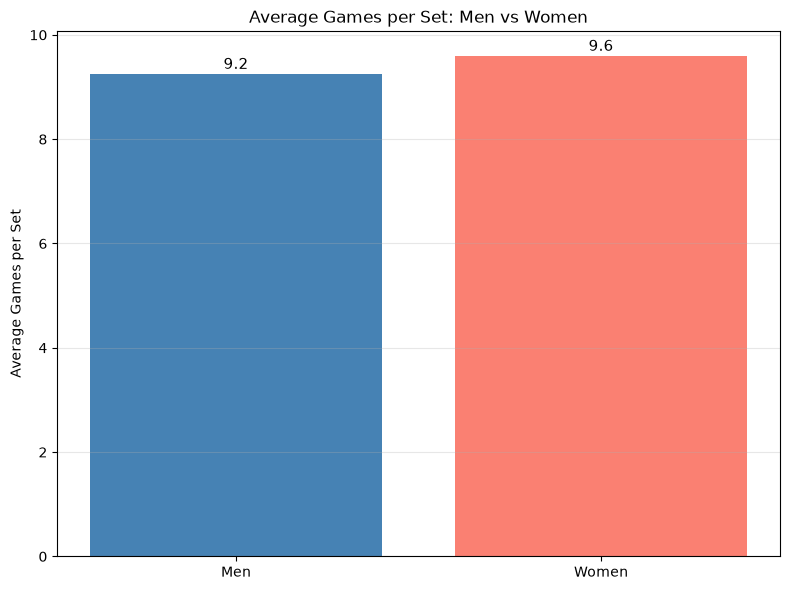

In [111]:
fig, ax = plt.subplots(figsize=(8, 6))


mean_by_gender = all_sets_df.groupby("gender")["total_games_in_set"].mean()

bars = ax.bar(["Men", "Women"], mean_by_gender.values, color=["steelblue", "salmon"])

# عدد دقیق میانگین را روی هر میله می‌نویسیم
for i, v in enumerate(mean_by_gender.values):
    ax.text(i, v + 0.1, f"{v:.1f}", ha="center", fontsize=11)

# عنوان و برچسب‌های نمودار را تنظیم می‌کنیم
ax.set_title("Average Games per Set: Men vs Women")
ax.set_ylabel("Average Games per Set")
ax.grid(axis="y", alpha=0.3)

# فاصله‌ها را خودکار تنظیم می‌کنیم
fig.tight_layout()

# نمودار را ذخیره می‌کنیم
# fig.savefig("charts/q12_games_per_set.png", dpi=300, bbox_inches="tight")

# نمودار را نمایش می‌دهیم
plt.show()